In [2]:
import pandas as pd 
import numpy as np

In [3]:
df = pd.read_csv('../data/heart_disease.csv')

In [4]:
df.head()

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0


In [5]:
X = df.drop("Heart Disease",axis = 1)
y = df["Heart Disease"]

In [6]:
numerical_features = df.select_dtypes(include = ["int64","float64"]).columns
categorical_features = df.select_dtypes(include = ["str"]).columns


In [7]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    stratify = y,
    random_state = 42,
    test_size = 0.20
)

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers = [
        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)
    ],
    remainder="passthrough"
)

In [9]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    random_state=42
)

rf.fit(X_train_processed,y_train)

y_pred = rf.predict(X_test_processed)

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\n Confusion Matrix:")
cm = confusion_matrix(y_test,y_pred)
print(cm)

Accuracy : 0.99
Precision: 1.0
Recall   : 0.9743589743589743
F1 Score : 0.987012987012987

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       122
           1       1.00      0.97      0.99        78

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200


 Confusion Matrix:
[[122   0]
 [  2  76]]


In [12]:
train_pred = rf.predict(X_train_processed)
test_pred = rf.predict(X_test_processed)



In [13]:
print(f"train dataset accuracy:{accuracy_score(y_train,train_pred)}")
print(f"test dataset accuracy:{accuracy_score(y_test,test_pred)}")

train dataset accuracy:1.0
test dataset accuracy:0.99


In [14]:
y_proba = rf.predict_proba(X_test_processed)[:,1]

In [18]:
from sklearn.metrics import roc_curve,roc_auc_score

fpr , tpr , thresholds = roc_curve(y_test,y_proba)
auc_score = roc_auc_score(y_test,y_proba)

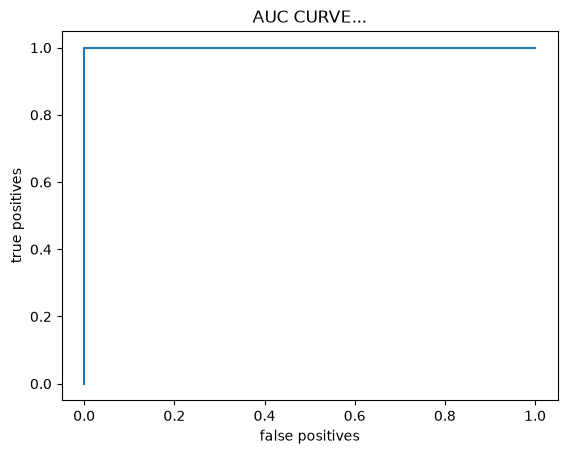

In [19]:
import matplotlib.pyplot as plt 

plt.plot(fpr,tpr,label=f"AUC SCORE:{auc_score}")
plt.title("AUC CURVE...")
plt.xlabel("false positives")
plt.ylabel("true positives")
plt.show()